In [1]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [2]:
import math

In [ ]:
class value:
    def __init__(self,value, _children=(), _op='', label=''):
        self.data = value
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None
        self.label = label

    def __neg__(self):
        return self * -1
    
    def __add__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data + other.data, _children=(self, other), _op='+')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __sub__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data - other.data, _children=(self, other), _op='-')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __mul__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data * other.data, _children=(self, other), _op='*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __truediv__(self, other):
        return self * other**-1

    
    def __radd__(self,other):
        return self + other
    
    def __rmul__(self,other):
        return self * other
    
    
    def __repr__(self):
        return f"value({self.data})"
    
    def exp(self):
        if not isinstance(self, value):
            self = value(self)
        
        x = self.data
        out = value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        if not isinstance(self, value):
            self = value(self)
        
        x = self.data
        out = value(x**other, (self,), f'pow{other}')

        def _backward():
            self.grad += other * (x**(other-1)) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        self.grad = 0.0
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

        out = value(t, _children=(self,), _op='tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):

        self.grad = 1.0
        # print(self.grad, self.label)
        topo = []
        visited = set()
        def build_topo(v):
            if v != None and v not in visited:
                # print(v.label)
                visited.add(v)
                for child in v._prev:
                    build_topo(child)#dfs

                # print(v.label)
                topo.append(v)

        build_topo(self)
        topo = topo[::-1]
        for node in topo:
            # print(node.label)
            node._backward()

In [54]:
a = value(3.0)
a = a.tanh()
print(a.data)

print(math.tanh(3))

0.9950547536867305
0.9950547536867305


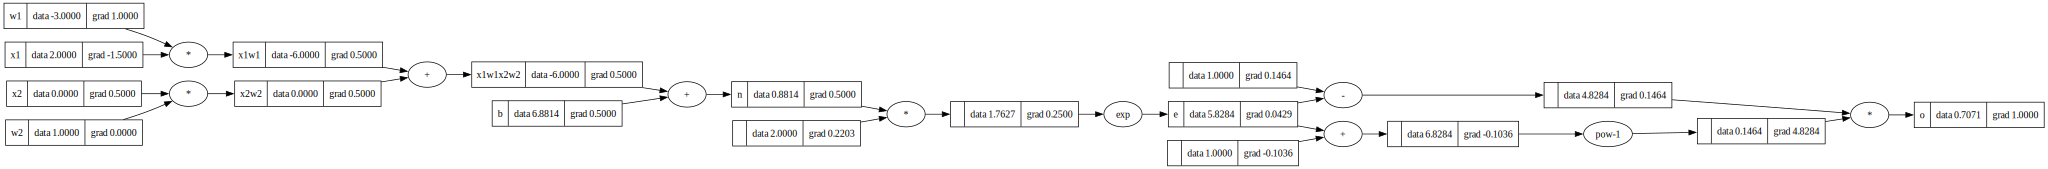

In [56]:
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2') 

w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

b = value(6.881373587019543, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'
# ----
e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [ ]:
# o.grad = 1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# x1w1 = w1 * x1; x1w1.label = 'x1w1'
# x2w2 = w2 * x2; x2w2.label = 'x2w2'
# x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'
o.backward()

# draw_dot(o)

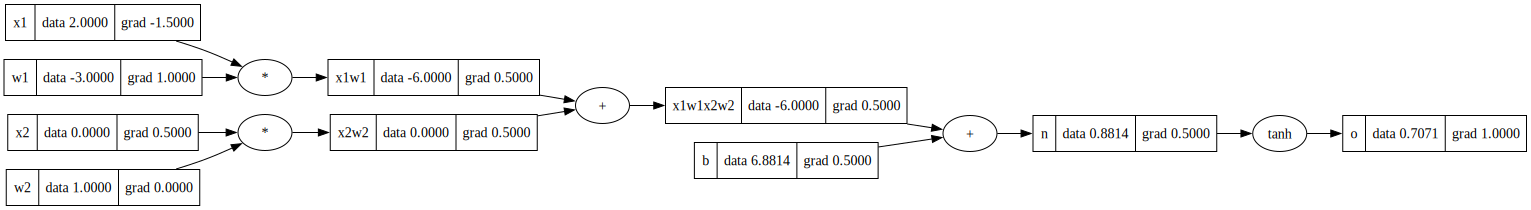

In [ ]:
draw_dot(o)